# Board2Notes — NAFNet-Small H100 RAM-Cache Full Training 40 Epoch

Bu notebook, smoke testte çalışan **NAFNet-Small** omurgasını full dataset üzerinde eğitmek için hazırlanmıştır.

Varsayılan tam eğitim ayarı:
- `smoke_mode = False`
- `epochs = 40`
- `manual_batch_size = 16`
- `batch_selection_mode = "manual"`
- `cache_train_in_ram = True` yani train split pre-resize RAM cache ile hızlandırılır
- `cache_val_in_ram = False` yani validation gereksiz RAM tüketmesin diye diskten okunur
- `val_every_epochs = 5`
- `save_every_epochs = 5`

Bu sürüm GAN/Discriminator kullanmaz. Eğitim supervised restoration şeklindedir: `L1 + SSIM + Edge`.


In [1]:
# ============================================================
# 0) Ortam kontrolü
# ============================================================

import os, sys, time, json, math, random, shutil, zipfile, gc
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Optional, Any

import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA H100 80GB HBM3
VRAM GB: 79.18


In [2]:
# ============================================================
# 1) Drive mount + proje konfigürasyonu
# ============================================================

from google.colab import drive
try:
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount uyarısı:", e)


def resolve_sd7k_zip():
    """Drive kökünde SD7K.zip / sd7k.zip / adında sd7k geçen zip dosyasını bulur."""
    mydrive = Path("/content/drive/MyDrive")
    candidates = [mydrive / "SD7K.zip", mydrive / "sd7k.zip", mydrive / "Sd7k.zip"]
    for p in candidates:
        if p.exists():
            return str(p)

    matches = sorted(
        [p for p in mydrive.glob("*.zip") if "sd7k" in p.name.lower()],
        key=lambda x: x.stat().st_size if x.exists() else 0,
        reverse=True,
    )
    if matches:
        return str(matches[0])

    matches = sorted(
        [p for p in Path("/content/drive").rglob("*.zip") if "sd7k" in p.name.lower()],
        key=lambda x: x.stat().st_size if x.exists() else 0,
        reverse=True,
    )
    if matches:
        return str(matches[0])

    raise FileNotFoundError("SD7K zip bulunamadı. Drive ana dizinine SD7K.zip koy.")


@dataclass
class TrainConfig:
    # Dataset
    zip_path: str = resolve_sd7k_zip()
    extract_dir: str = "/content/sd7k_extracted"

    # Output
    project_dir: str = "/content/drive/MyDrive/ysaproj"
    output_root: str = "/content/runs"
    run_name: str = "board2notes_nafnet_small_h100_ramcache_full40"

    # Smoke test: full dataset yerine küçük subset kullanılır.
    smoke_mode: bool = False
    smoke_train_limit: int = 1024
    smoke_val_limit: int = 128
    smoke_test_limit: int = 128

    # Eğitim
    epochs: int = 40
    image_size: int = 512
    seed: int = 42

    # Batch: smoke testte benchmark ile tüm cache'i tekrar kurmayalım; manual daha hızlı/güvenli.
    batch_selection_mode: str = "manual"  # "manual" veya "throughput"
    manual_batch_size: int = 16
    batch_candidates: Tuple[int, ...] = (32, 24, 20, 16, 12, 8)
    benchmark_warmup_steps: int = 1
    benchmark_measure_steps: int = 3
    max_vram_fraction: float = 0.88

    # DataLoader / RAM cache
    cache_train_in_ram: bool = True
    cache_val_in_ram: bool = False
    cache_test_in_ram: bool = False
    cache_preresize: bool = True
    num_workers: int = 8
    prefetch_factor: int = 4
    persistent_workers: bool = True
    pin_memory: bool = True

    # NAFNet-Small
    naf_width: int = 32
    naf_enc_blks: Tuple[int, ...] = (2, 2, 4, 8)
    naf_middle_blks: int = 12
    naf_dec_blks: Tuple[int, ...] = (2, 2, 2, 2)
    naf_dw_expand: int = 2
    naf_ffn_expand: int = 2
    naf_dropout: float = 0.0

    # Optimizer
    lr: float = 2e-4
    weight_decay: float = 1e-4
    beta1: float = 0.9
    beta2: float = 0.99
    ema_decay: float = 0.999

    # Loss weights: GAN yok, supervised restoration.
    lambda_l1: float = 1.0
    lambda_ssim: float = 0.5
    lambda_edge: float = 0.1
    aux_loss_downsample: int = 2

    # Precision / performance
    amp_dtype: str = "bf16"  # H100 için bf16
    use_channels_last: bool = True
    use_torch_compile: bool = False
    compile_mode: str = "default"

    # Validation / save
    val_every_epochs: int = 5
    save_every_epochs: int = 5
    max_val_batches: int = 32
    keep_last_n_checkpoints: int = 3

    # Resume
    resume_ckpt: str = ""


CFG = TrainConfig()

timestamp = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path(CFG.output_root) / f"{CFG.run_name}_{timestamp}"
CKPT_DIR = RUN_DIR / "checkpoints"
SAMPLE_DIR = RUN_DIR / "samples"
PRED_DIR = RUN_DIR / "predictions"
LOG_DIR = RUN_DIR / "logs"
for d in [RUN_DIR, CKPT_DIR, SAMPLE_DIR, PRED_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DRIVE_RUNS_DIR = Path(CFG.project_dir) / "runs"
DRIVE_RUNS_DIR.mkdir(parents=True, exist_ok=True)

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2, ensure_ascii=False)

print("Run dir:", RUN_DIR)
print("Zip path:", CFG.zip_path)
print("Extract dir:", CFG.extract_dir)
print("Smoke mode:", CFG.smoke_mode)
print("Epochs:", CFG.epochs)
print("Manual batch:", CFG.manual_batch_size)
print("Cache train/val:", CFG.cache_train_in_ram, CFG.cache_val_in_ram)


Mounted at /content/drive
Run dir: /content/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919
Zip path: /content/drive/MyDrive/SD7K.zip
Extract dir: /content/sd7k_extracted
Smoke mode: False
Epochs: 40
Manual batch: 16
Cache train/val: True False


In [3]:
# ============================================================
# 2) Seed, CUDA ayarları, zip açma
# ============================================================

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception as e:
        print("matmul precision ayarı geçilemedi:", e)


def list_tree(root: Path, max_depth: int = 2, max_items: int = 80):
    root = Path(root)
    shown = 0
    for p in root.rglob("*"):
        try:
            depth = len(p.relative_to(root).parts)
        except Exception:
            continue
        if depth > max_depth:
            continue
        print("  " * depth + ("[D] " if p.is_dir() else "[F] ") + p.name)
        shown += 1
        if shown >= max_items:
            print("...")
            break


def extract_zip_if_needed(zip_path: str, extract_dir: str):
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)
    marker = extract_dir / ".extract_done"

    if not zip_path.exists():
        raise FileNotFoundError(f"Zip bulunamadı: {zip_path}")

    if marker.exists():
        print("Dataset daha önce açılmış görünüyor:", extract_dir)
        return

    extract_dir.mkdir(parents=True, exist_ok=True)
    print("Zip açılıyor:", zip_path)
    print("Hedef:", extract_dir)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    marker.write_text("done", encoding="utf-8")
    print("Zip açma tamamlandı.")
    list_tree(extract_dir, max_depth=3)

extract_zip_if_needed(CFG.zip_path, CFG.extract_dir)


Zip açılıyor: /content/drive/MyDrive/SD7K.zip
Hedef: /content/sd7k_extracted
Zip açma tamamlandı.
  [D] train
  [F] .extract_done
  [D] test
    [D] input
    [D] target
    [D] input
    [D] target
      [F] IMG_5824.png
      [F] IMG_5293.png
      [F] IMG_1597.png
      [F] IMG_3856.png
      [F] IMG_4369.png
      [F] IMG_2682.png
      [F] IMG_5329.png
      [F] IMG_6665.png
      [F] IMG_3526.png
      [F] IMG_2846.png
      [F] IMG_4559.png
      [F] IMG_0203.png
      [F] IMG_3067.png
      [F] IMG_5081.png
      [F] IMG_3178.png
      [F] IMG_7247.png
      [F] IMG_4636.png
      [F] IMG_7516.png
      [F] IMG_6325.png
      [F] IMG_6981.png
      [F] IMG_5846.png
      [F] IMG_2543.png
      [F] IMG_8392.png
      [F] IMG_0393.png
      [F] IMG_8266.png
      [F] IMG_3560.png
      [F] IMG_0101.png
      [F] IMG_5661.png
      [F] IMG_0456.png
      [F] IMG_5686.png
      [F] IMG_3999.png
      [F] IMG_2000.png
      [F] IMG_4593.png
      [F] IMG_1212.png
      [F] IMG_6711.

In [4]:
# ============================================================
# 3) SD7K paired input/target köklerini otomatik bulma + smoke subset
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image_path(p: Path) -> bool:
    p = Path(p)
    return p.is_file() and p.suffix.lower() in IMAGE_EXTS


def list_images(d: Path) -> List[Path]:
    d = Path(d)
    if not d.exists() or not d.is_dir():
        return []
    return sorted([p for p in d.iterdir() if is_image_path(p)])


def count_images(d: Path) -> int:
    return len(list_images(Path(d)))


def normalize_stem(stem: str) -> str:
    s = stem.lower()
    for tok in ["_input", "-input", "_target", "-target", "_shadow", "-shadow", "_gt", "-gt", "_clean", "-clean", "_label", "-label"]:
        if s.endswith(tok):
            s = s[: -len(tok)]
    return s


def pair_input_target_dirs(input_dir: Path, target_dir: Path) -> List[Tuple[Path, Path]]:
    input_files = list_images(input_dir)
    target_files = list_images(target_dir)
    if not input_files or not target_files:
        return []

    target_by_stem = {p.stem: p for p in target_files}
    pairs = [(inp, target_by_stem[inp.stem]) for inp in input_files if inp.stem in target_by_stem]
    if len(pairs) >= max(1, int(0.5 * min(len(input_files), len(target_files)))):
        return pairs

    target_by_norm = {normalize_stem(p.stem): p for p in target_files}
    pairs = []
    for inp in input_files:
        key = normalize_stem(inp.stem)
        if key in target_by_norm:
            pairs.append((inp, target_by_norm[key]))
    if len(pairs) >= max(1, int(0.5 * min(len(input_files), len(target_files)))):
        return pairs

    if len(input_files) == len(target_files):
        return list(zip(input_files, target_files))

    return []


def find_input_target_in_split(split_dir: Path) -> Optional[Tuple[Path, Path]]:
    split_dir = Path(split_dir)
    if not split_dir.exists() or not split_dir.is_dir():
        return None

    input_names = ["input", "inputs", "inp", "shadow", "shadows", "degraded", "degrade", "source", "src", "x"]
    target_names = ["target", "targets", "gt", "gts", "clean", "cleans", "label", "labels", "groundtruth", "ground_truth", "y"]

    children = [p for p in split_dir.iterdir() if p.is_dir()]
    lower_map = {p.name.lower(): p for p in children}

    input_dir = next((lower_map[n] for n in input_names if n in lower_map), None)
    target_dir = next((lower_map[n] for n in target_names if n in lower_map), None)

    if input_dir and target_dir and count_images(input_dir) > 0 and count_images(target_dir) > 0:
        return input_dir, target_dir
    return None


def find_paired_roots(root: Path) -> List[Tuple[Path, Path, str]]:
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Dataset extract klasörü bulunamadı: {root}")

    candidates = []
    split_aliases = {
        "train": ["train", "training"],
        "val": ["val", "valid", "validation"],
        "test": ["test", "testing"],
    }

    for canonical, names in split_aliases.items():
        for name in names:
            sd = root / name
            found = find_input_target_in_split(sd)
            if found:
                candidates.append((found[0], found[1], canonical))

    for sub in root.rglob("*"):
        if not sub.is_dir():
            continue
        try:
            depth = len(sub.relative_to(root).parts)
        except Exception:
            depth = 99
        if depth > 4:
            continue

        lname = sub.name.lower()
        split_name = None
        if lname in ["train", "training"]:
            split_name = "train"
        elif lname in ["val", "valid", "validation"]:
            split_name = "val"
        elif lname in ["test", "testing"]:
            split_name = "test"

        if split_name:
            found = find_input_target_in_split(sub)
            if found:
                item = (found[0], found[1], split_name)
                if item not in candidates:
                    candidates.append(item)

    found = find_input_target_in_split(root)
    if found:
        item = (found[0], found[1], "all")
        if item not in candidates:
            candidates.append(item)

    return candidates


def split_pairs_randomly(pairs: List[Tuple[Path, Path]], train_ratio=0.85, val_ratio=0.10, seed=42):
    pairs = list(pairs)
    rng = random.Random(seed)
    rng.shuffle(pairs)
    n = len(pairs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_pairs = pairs[:n_train]
    val_pairs = pairs[n_train:n_train+n_val]
    test_pairs = pairs[n_train+n_val:]
    if not test_pairs and len(val_pairs) > 1:
        k = max(1, len(val_pairs)//5)
        test_pairs = val_pairs[-k:]
        val_pairs = val_pairs[:-k]
    return train_pairs, val_pairs, test_pairs


def detect_dataset_splits(extract_dir: str):
    root = Path(extract_dir)
    print("Dataset kökü:", root)
    candidates = find_paired_roots(root)
    if not candidates:
        print("Paired input/target klasörü bulunamadı. Klasör önizleme:")
        list_tree(root, max_depth=4, max_items=120)
        raise RuntimeError("Paired dataset yapısı otomatik bulunamadı.")

    print("Bulunan paired klasörler:")
    for input_dir, target_dir, split_name in candidates:
        print(f"split={split_name:5s} | input={input_dir} ({count_images(input_dir)}) | target={target_dir} ({count_images(target_dir)})")

    split_to_pairs: Dict[str, List[Tuple[Path, Path]]] = {}
    for input_dir, target_dir, split_name in candidates:
        pairs = pair_input_target_dirs(input_dir, target_dir)
        if pairs:
            split_to_pairs.setdefault(split_name, []).extend(pairs)

    train_pairs = split_to_pairs.get("train", [])
    val_pairs = split_to_pairs.get("val", [])
    test_pairs = split_to_pairs.get("test", [])

    if not train_pairs and "all" in split_to_pairs:
        train_pairs, val_pairs, test_pairs = split_pairs_randomly(split_to_pairs["all"], seed=CFG.seed)
    if train_pairs and (not val_pairs or not test_pairs):
        train_pairs, val_pairs, test_pairs = split_pairs_randomly(train_pairs, seed=CFG.seed)
    if not test_pairs:
        test_pairs = list(val_pairs)

    if not train_pairs:
        raise RuntimeError("Train pairs bulunamadı.")

    print("Final pair sayıları:")
    print("Train:", len(train_pairs), "Val:", len(val_pairs), "Test:", len(test_pairs))
    print("Örnek input :", train_pairs[0][0])
    print("Örnek target:", train_pairs[0][1])
    return train_pairs, val_pairs, test_pairs


train_pairs, val_pairs, test_pairs = detect_dataset_splits(CFG.extract_dir)

if CFG.smoke_mode:
    print("\nSMOKE MODE aktif: küçük subset kullanılacak.")
    rng = random.Random(CFG.seed)
    train_pairs = list(train_pairs); val_pairs = list(val_pairs); test_pairs = list(test_pairs)
    rng.shuffle(train_pairs); rng.shuffle(val_pairs); rng.shuffle(test_pairs)
    train_pairs = train_pairs[:int(CFG.smoke_train_limit)]
    val_pairs = val_pairs[:int(CFG.smoke_val_limit)]
    test_pairs = test_pairs[:int(CFG.smoke_test_limit)]
    print("Smoke train:", len(train_pairs), "Smoke val:", len(val_pairs), "Smoke test:", len(test_pairs))


Dataset kökü: /content/sd7k_extracted
Bulunan paired klasörler:
split=train | input=/content/sd7k_extracted/train/input (6479) | target=/content/sd7k_extracted/train/target (6478)
split=test  | input=/content/sd7k_extracted/test/input (760) | target=/content/sd7k_extracted/test/target (760)
Final pair sayıları:
Train: 5506 Val: 647 Test: 325
Örnek input : /content/sd7k_extracted/train/input/IMG_7378.png
Örnek target: /content/sd7k_extracted/train/target/IMG_7378.png


In [5]:
# ============================================================
# 4) Paired dataset + RAM cache + pre-resize
# ============================================================

def pil_resize(img: Image.Image, size_hw: Tuple[int, int]) -> Image.Image:
    h, w = size_hw
    return img.resize((w, h), Image.BICUBIC)


def pil_crop(img: Image.Image, top: int, left: int, height: int, width: int) -> Image.Image:
    return img.crop((left, top, left + width, top + height))


def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    arr = np.array(img, dtype=np.float32) / 255.0
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    ten = torch.from_numpy(arr).permute(2, 0, 1).contiguous()
    return ten


def estimate_pairs_ram_mb(cache: List[Tuple[np.ndarray, np.ndarray]]) -> float:
    return sum(a.nbytes + b.nbytes for a, b in cache) / 1024**2


class PairedBoardEnhancementDataset(Dataset):
    def __init__(
        self,
        pairs: List[Tuple[Path, Path]],
        image_size: int = 512,
        split: str = "train",
        augment: bool = True,
        cache_in_ram: bool = False,
        cache_preresize: bool = True,
    ):
        self.pairs = list(pairs)
        self.image_size = int(image_size)
        self.split = split
        self.augment = augment and split == "train"
        self.cache_in_ram = bool(cache_in_ram)
        self.cache_preresize = bool(cache_preresize)
        if not self.pairs:
            raise ValueError(f"{split} split pair listesi boş.")

        self._cache: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
        if self.cache_in_ram:
            print(f"[{split}] {len(self.pairs)} çift RAM'e yükleniyor (pre-resize min_side={self.image_size})...")
            cache = []
            for inp_path, tar_path in tqdm(self.pairs, desc=f"cache {split}", leave=False):
                inp_path = Path(inp_path); tar_path = Path(tar_path)
                try:
                    inp_img = Image.open(inp_path).convert("RGB")
                    tar_img = Image.open(tar_path).convert("RGB")
                    if inp_img.size != tar_img.size:
                        tar_img = tar_img.resize(inp_img.size, Image.BICUBIC)

                    if self.cache_preresize:
                        w, h = inp_img.size
                        min_side = min(w, h)
                        if min_side > self.image_size:
                            scale = self.image_size / float(min_side)
                            new_w = max(self.image_size, int(round(w * scale)))
                            new_h = max(self.image_size, int(round(h * scale)))
                            inp_img = inp_img.resize((new_w, new_h), Image.BICUBIC)
                            tar_img = tar_img.resize((new_w, new_h), Image.BICUBIC)

                    inp_arr = np.asarray(inp_img, dtype=np.uint8).copy()
                    tar_arr = np.asarray(tar_img, dtype=np.uint8).copy()
                    inp_arr.setflags(write=False); tar_arr.setflags(write=False)
                    cache.append((inp_arr, tar_arr))
                    inp_img.close(); tar_img.close()
                except Exception as e:
                    raise RuntimeError(f"RAM cache yükleme hatası: {inp_path} | {tar_path} | {e}")

            self._cache = cache
            print(f"[{split}] RAM cache hazır. pair={len(cache)} | yaklaşık RAM={estimate_pairs_ram_mb(cache):.1f} MB")

    def __len__(self):
        return len(self.pairs)

    def _resize_min_side_if_needed(self, img: Image.Image, target: Image.Image):
        w, h = img.size
        min_side = min(w, h)
        if min_side >= self.image_size:
            return img, target
        scale = self.image_size / max(1, min_side)
        new_w = int(round(w * scale)); new_h = int(round(h * scale))
        return pil_resize(img, (new_h, new_w)), pil_resize(target, (new_h, new_w))

    def _paired_random_crop(self, img: Image.Image, target: Image.Image):
        img, target = self._resize_min_side_if_needed(img, target)
        w, h = img.size; th = tw = self.image_size
        if w < tw or h < th:
            return pil_resize(img, (th, tw)), pil_resize(target, (th, tw))
        if w == tw and h == th:
            return img, target
        top = random.randint(0, h - th)
        left = random.randint(0, w - tw)
        return pil_crop(img, top, left, th, tw), pil_crop(target, top, left, th, tw)

    def _paired_center_resize(self, img: Image.Image, target: Image.Image):
        return pil_resize(img, (self.image_size, self.image_size)), pil_resize(target, (self.image_size, self.image_size))

    def __getitem__(self, idx):
        inp_path, tar_path = self.pairs[idx]
        inp_path = Path(inp_path); tar_path = Path(tar_path)
        if self._cache is not None:
            inp_arr, tar_arr = self._cache[idx]
            inp = Image.fromarray(inp_arr).copy()
            tar = Image.fromarray(tar_arr).copy()
        else:
            try:
                inp = Image.open(inp_path).convert("RGB")
                tar = Image.open(tar_path).convert("RGB")
            except Exception as e:
                raise RuntimeError(f"Görüntü okunamadı: {inp_path} | {tar_path} | {e}")

        if inp.size != tar.size:
            tar = tar.resize(inp.size, Image.BICUBIC)

        if self.augment:
            inp, tar = self._paired_random_crop(inp, tar)
        else:
            inp, tar = self._paired_center_resize(inp, tar)

        inp_t = pil_to_tensor(inp) * 2.0 - 1.0
        tar_t = pil_to_tensor(tar) * 2.0 - 1.0
        return {"input": inp_t, "target": tar_t, "name": inp_path.stem, "input_path": str(inp_path), "target_path": str(tar_path)}


def make_loader(pairs, split, batch_size, num_workers=None, prefetch_factor=None):
    if num_workers is None:
        num_workers = int(CFG.num_workers)
    if prefetch_factor is None:
        prefetch_factor = int(CFG.prefetch_factor)

    if split == "train":
        cache_in_ram = bool(CFG.cache_train_in_ram)
    elif split == "val":
        cache_in_ram = bool(CFG.cache_val_in_ram)
    elif split == "test":
        cache_in_ram = bool(CFG.cache_test_in_ram)
    else:
        cache_in_ram = False

    ds = PairedBoardEnhancementDataset(
        pairs=pairs,
        image_size=CFG.image_size,
        split=split,
        augment=(split == "train"),
        cache_in_ram=cache_in_ram,
        cache_preresize=CFG.cache_preresize,
    )

    kwargs = dict(
        dataset=ds,
        batch_size=int(batch_size),
        shuffle=(split == "train"),
        num_workers=int(num_workers),
        pin_memory=bool(CFG.pin_memory),
        persistent_workers=bool(CFG.persistent_workers) if int(num_workers) > 0 else False,
        drop_last=(split == "train"),
    )
    if int(num_workers) > 0:
        kwargs["prefetch_factor"] = int(prefetch_factor)
    return ds, DataLoader(**kwargs)

# Preview
preview_ds = PairedBoardEnhancementDataset(train_pairs[:8], CFG.image_size, "train", True, cache_in_ram=False)
preview_loader = DataLoader(preview_ds, batch_size=2, shuffle=True, num_workers=0)
preview_batch = next(iter(preview_loader))
print("Preview input:", preview_batch["input"].shape)
print("Preview target:", preview_batch["target"].shape)


Preview input: torch.Size([2, 3, 512, 512])
Preview target: torch.Size([2, 3, 512, 512])


In [6]:
# ============================================================
# 5) NAFNet-Small model tanımı
# ============================================================

class LayerNorm2d(nn.Module):
    def __init__(self, channels: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(1, channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.eps = eps

    def forward(self, x):
        mu = x.mean(dim=1, keepdim=True)
        var = (x - mu).pow(2).mean(dim=1, keepdim=True)
        x = (x - mu) / torch.sqrt(var + self.eps)
        return x * self.weight + self.bias


class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2


class NAFBlock(nn.Module):
    def __init__(self, c, dw_expand=2, ffn_expand=2, dropout=0.0):
        super().__init__()
        dw_channel = c * dw_expand
        self.norm1 = LayerNorm2d(c)
        self.conv1 = nn.Conv2d(c, dw_channel, kernel_size=1, padding=0, stride=1)
        self.conv2 = nn.Conv2d(dw_channel, dw_channel, kernel_size=3, padding=1, stride=1, groups=dw_channel)
        self.sg = SimpleGate()
        self.sca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dw_channel // 2, dw_channel // 2, kernel_size=1, padding=0, stride=1),
        )
        self.conv3 = nn.Conv2d(dw_channel // 2, c, kernel_size=1, padding=0, stride=1)
        self.dropout1 = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        ffn_channel = c * ffn_expand
        self.norm2 = LayerNorm2d(c)
        self.conv4 = nn.Conv2d(c, ffn_channel, kernel_size=1, padding=0, stride=1)
        self.conv5 = nn.Conv2d(ffn_channel // 2, c, kernel_size=1, padding=0, stride=1)
        self.dropout2 = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.beta = nn.Parameter(torch.zeros(1, c, 1, 1))
        self.gamma = nn.Parameter(torch.zeros(1, c, 1, 1))

    def forward(self, inp):
        x = inp
        y = self.norm1(x)
        y = self.conv1(y)
        y = self.conv2(y)
        y = self.sg(y)
        y = y * self.sca(y)
        y = self.conv3(y)
        y = self.dropout1(y)
        x = x + y * self.beta

        y = self.norm2(x)
        y = self.conv4(y)
        y = self.sg(y)
        y = self.conv5(y)
        y = self.dropout2(y)
        return x + y * self.gamma


class NAFNet(nn.Module):
    def __init__(
        self,
        img_channel=3,
        width=32,
        middle_blk_num=12,
        enc_blk_nums=(2, 2, 4, 8),
        dec_blk_nums=(2, 2, 2, 2),
        dw_expand=2,
        ffn_expand=2,
        dropout=0.0,
    ):
        super().__init__()
        self.intro = nn.Conv2d(img_channel, width, kernel_size=3, padding=1, stride=1)
        self.ending = nn.Conv2d(width, img_channel, kernel_size=3, padding=1, stride=1)

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        chan = width
        for num in enc_blk_nums:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan, dw_expand, ffn_expand, dropout) for _ in range(num)]))
            self.downs.append(nn.Conv2d(chan, chan * 2, kernel_size=2, stride=2))
            chan *= 2

        self.middle_blks = nn.Sequential(*[NAFBlock(chan, dw_expand, ffn_expand, dropout) for _ in range(middle_blk_num)])

        for num in dec_blk_nums:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, chan * 2, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan, dw_expand, ffn_expand, dropout) for _ in range(num)]))

        self.padder_size = 2 ** len(enc_blk_nums)

    def check_image_size(self, x):
        _, _, h, w = x.size()
        mod_pad_h = (self.padder_size - h % self.padder_size) % self.padder_size
        mod_pad_w = (self.padder_size - w % self.padder_size) % self.padder_size
        if mod_pad_h != 0 or mod_pad_w != 0:
            x = F.pad(x, (0, mod_pad_w, 0, mod_pad_h), mode="reflect")
        return x, h, w

    def forward(self, inp):
        x, h, w = self.check_image_size(inp)
        encs = []
        x = self.intro(x)
        for encoder, down in zip(self.encoders, self.downs):
            x = encoder(x)
            encs.append(x)
            x = down(x)
        x = self.middle_blks(x)
        for decoder, up, enc_skip in zip(self.decoders, self.ups, encs[::-1]):
            x = up(x)
            x = x + enc_skip
            x = decoder(x)
        x = self.ending(x)
        x = x + inp if x.shape[-2:] == inp.shape[-2:] else x[..., :h, :w] + inp[..., :h, :w]
        return x[..., :h, :w]


def make_model(device):
    model = NAFNet(
        img_channel=3,
        width=CFG.naf_width,
        middle_blk_num=CFG.naf_middle_blks,
        enc_blk_nums=CFG.naf_enc_blks,
        dec_blk_nums=CFG.naf_dec_blks,
        dw_expand=CFG.naf_dw_expand,
        ffn_expand=CFG.naf_ffn_expand,
        dropout=CFG.naf_dropout,
    ).to(device)
    if CFG.use_channels_last:
        model = model.to(memory_format=torch.channels_last)
    return model

# Parametre sayısı hızlı kontrol
_tmp = make_model("cuda" if torch.cuda.is_available() else "cpu")
param_count = sum(p.numel() for p in _tmp.parameters())
print(f"NAFNet-Small params: {param_count/1e6:.2f}M")
del _tmp
if torch.cuda.is_available():
    torch.cuda.empty_cache()


NAFNet-Small params: 29.16M


In [7]:
# ============================================================
# 6) Losslar, metrikler, checkpoint/sample yardımcıları
# ============================================================

def get_amp_dtype():
    if CFG.amp_dtype.lower() == "bf16":
        return torch.bfloat16
    if CFG.amp_dtype.lower() == "fp16":
        return torch.float16
    return torch.float32

amp_dtype = get_amp_dtype()


def autocast_context():
    return torch.autocast(
        device_type="cuda",
        dtype=amp_dtype,
        enabled=(torch.cuda.is_available() and amp_dtype in [torch.float16, torch.bfloat16]),
    )


def to_01(x):
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


def aux_loss_tensors(pred, target):
    if int(CFG.aux_loss_downsample) > 1:
        scale = int(CFG.aux_loss_downsample)
        pred = F.avg_pool2d(pred, kernel_size=scale, stride=scale)
        target = F.avg_pool2d(target, kernel_size=scale, stride=scale)
    return pred, target


def ssim_loss(pred, target, window_size=7, eps=1e-6):
    # Basit differentiable SSIM loss. Input [-1,1] varsayılır, [0,1]'e çekilir.
    x = to_01(pred)
    y = to_01(target)
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu_x = F.avg_pool2d(x, window_size, stride=1, padding=window_size//2)
    mu_y = F.avg_pool2d(y, window_size, stride=1, padding=window_size//2)
    sigma_x = F.avg_pool2d(x * x, window_size, stride=1, padding=window_size//2) - mu_x * mu_x
    sigma_y = F.avg_pool2d(y * y, window_size, stride=1, padding=window_size//2) - mu_y * mu_y
    sigma_xy = F.avg_pool2d(x * y, window_size, stride=1, padding=window_size//2) - mu_x * mu_y
    ssim = ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / ((mu_x**2 + mu_y**2 + C1) * (sigma_x + sigma_y + C2) + eps)
    return 1.0 - ssim.mean()

_sobel_cache = {}

def get_sobel_kernels(device, dtype):
    key = (str(device), str(dtype))
    if key in _sobel_cache:
        return _sobel_cache[key]
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=dtype, device=device).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=dtype, device=device).view(1,1,3,3)
    kx = kx.repeat(3,1,1,1)
    ky = ky.repeat(3,1,1,1)
    _sobel_cache[key] = (kx, ky)
    return kx, ky


def edge_map(x):
    x01 = to_01(x)
    kx, ky = get_sobel_kernels(x01.device, x01.dtype)
    gx = F.conv2d(x01, kx, padding=1, groups=3)
    gy = F.conv2d(x01, ky, padding=1, groups=3)
    return torch.sqrt(gx * gx + gy * gy + 1e-6)


def edge_loss(pred, target):
    return F.l1_loss(edge_map(pred), edge_map(target))


def compute_psnr(pred, target):
    pred01 = to_01(pred).detach()
    target01 = to_01(target).detach()
    mse = F.mse_loss(pred01, target01).clamp_min(1e-10)
    return 10.0 * torch.log10(1.0 / mse)


def compute_total_loss(pred, target):
    p_aux, t_aux = aux_loss_tensors(pred, target)
    l1 = F.l1_loss(pred, target)
    sl = ssim_loss(p_aux, t_aux)
    el = edge_loss(p_aux, t_aux)
    total = CFG.lambda_l1 * l1 + CFG.lambda_ssim * sl + CFG.lambda_edge * el
    return total, {"l1": l1, "ssim_loss": sl, "edge": el}


@torch.no_grad()
def update_ema(model, ema_model, decay=0.999):
    msd = model.state_dict()
    for k, v in ema_model.state_dict().items():
        if k in msd and v.dtype.is_floating_point:
            v.copy_(v * decay + msd[k].detach() * (1.0 - decay))
        elif k in msd:
            v.copy_(msd[k])


def make_optimizer(model):
    try:
        return torch.optim.AdamW(
            model.parameters(), lr=CFG.lr, betas=(CFG.beta1, CFG.beta2), weight_decay=CFG.weight_decay, fused=True
        )
    except TypeError:
        return torch.optim.AdamW(
            model.parameters(), lr=CFG.lr, betas=(CFG.beta1, CFG.beta2), weight_decay=CFG.weight_decay
        )


def tensor_to_pil(x: torch.Tensor) -> Image.Image:
    x = x.detach().float().cpu()
    if x.ndim == 4:
        x = x[0]
    x = to_01(x)
    arr = x.permute(1, 2, 0).numpy()
    arr = (arr * 255.0).round().astype(np.uint8)
    return Image.fromarray(arr)


def save_sample_grid(inp, pred, target, path: Path, max_items=4):
    n = min(max_items, inp.shape[0])
    rows = []
    for i in range(n):
        imgs = [tensor_to_pil(inp[i]), tensor_to_pil(pred[i]), tensor_to_pil(target[i])]
        w, h = imgs[0].size
        row = Image.new("RGB", (w * 3, h), "white")
        for j, im in enumerate(imgs):
            row.paste(im, (j*w, 0))
        rows.append(row)
    grid = Image.new("RGB", (rows[0].size[0], rows[0].size[1] * len(rows)), "white")
    for i, row in enumerate(rows):
        grid.paste(row, (0, i * row.size[1]))
    path.parent.mkdir(parents=True, exist_ok=True)
    grid.save(path)


def save_checkpoint(epoch, model, ema_model, optimizer, best_score, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
    torch.save({
        "epoch": int(epoch),
        "best_score": float(best_score),
        "model": raw_model.state_dict(),
        "model_ema": ema_model.state_dict() if ema_model is not None else None,
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "cfg": asdict(CFG),
    }, path)


def load_checkpoint(path, model, ema_model=None, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"], strict=True)
    if ema_model is not None and ckpt.get("model_ema") is not None:
        ema_model.load_state_dict(ckpt["model_ema"], strict=True)
    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])
    return int(ckpt.get("epoch", 0)) + 1, float(ckpt.get("best_score", 1e9))


In [8]:
# ============================================================
# 7) DataLoader, model, optimizer kurulumu
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
if device != "cuda":
    raise RuntimeError("Bu notebook H100/CUDA GPU için tasarlandı.")


def one_train_step_for_benchmark(model, opt, batch):
    inp = batch["input"].to(device, non_blocking=True)
    target = batch["target"].to(device, non_blocking=True)
    if CFG.use_channels_last:
        inp = inp.to(memory_format=torch.channels_last)
        target = target.to(memory_format=torch.channels_last)
    opt.zero_grad(set_to_none=True)
    with autocast_context():
        pred = model(inp)
        loss, _ = compute_total_loss(pred, target)
    loss.backward()
    opt.step()


def benchmark_batch_size(bs: int):
    result = {"batch_size": bs, "ok": False, "images_per_sec": 0.0, "peak_gb": None, "error": ""}
    try:
        gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        # Benchmark loader'da cache açık kalabilir; smoke subset küçük olduğu için sorun değil.
        _, loader = make_loader(train_pairs, "train", bs, num_workers=CFG.num_workers, prefetch_factor=CFG.prefetch_factor)
        model = make_model(device)
        opt = make_optimizer(model)
        model.train()
        measured_images = 0; measured_steps = 0; t0 = None
        max_steps = CFG.benchmark_warmup_steps + CFG.benchmark_measure_steps
        for i, batch in enumerate(loader):
            if i >= max_steps:
                break
            if i == CFG.benchmark_warmup_steps:
                torch.cuda.synchronize(); t0 = time.time()
            one_train_step_for_benchmark(model, opt, batch)
            if i >= CFG.benchmark_warmup_steps:
                measured_steps += 1
                measured_images += int(batch["input"].shape[0])
        torch.cuda.synchronize()
        elapsed = max(1e-6, time.time() - (t0 or time.time()))
        peak_gb = torch.cuda.max_memory_allocated() / 1024**3
        total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
        if measured_steps <= 0:
            result.update({"error": "no measured steps", "peak_gb": peak_gb})
        elif peak_gb > total_gb * CFG.max_vram_fraction:
            result.update({"error": f"peak {peak_gb:.1f}GB > budget", "peak_gb": peak_gb})
        else:
            result.update({"ok": True, "images_per_sec": measured_images / elapsed, "peak_gb": peak_gb})
        del model, opt, loader
        gc.collect(); torch.cuda.empty_cache()
        return result
    except RuntimeError as e:
        msg = str(e)
        if "out of memory" in msg.lower() or "cuda" in msg.lower():
            result.update({"error": msg[:300]})
            gc.collect(); torch.cuda.empty_cache()
            return result
        raise
    except Exception as e:
        result.update({"error": str(e)[:300]})
        gc.collect(); torch.cuda.empty_cache()
        return result


def select_batch_size():
    mode = str(CFG.batch_selection_mode).lower()
    if mode == "manual":
        print("Manual batch_size:", CFG.manual_batch_size)
        return int(CFG.manual_batch_size)

    print("Throughput batch benchmark başlıyor...")
    results = []
    for bs in CFG.batch_candidates:
        res = benchmark_batch_size(int(bs))
        results.append(res)
        peak = f"{res['peak_gb']:.1f}GB" if res.get("peak_gb") else "?"
        ips = f"{res['images_per_sec']:.1f} img/s" if res.get("ok") else "-"
        print(f"  batch={bs:<4} | ok={res['ok']} | {ips:<14} | peak={peak} | {res.get('error','')}")
    ok = [r for r in results if r.get("ok")]
    with open(LOG_DIR / "batch_benchmark.json", "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    if not ok:
        print("Benchmark başarısız, manual batch kullanılacak.")
        return int(CFG.manual_batch_size)
    best = max(ok, key=lambda r: r["images_per_sec"])
    print("Seçilen batch_size:", best["batch_size"], f"({best['images_per_sec']:.1f} img/s)")
    return int(best["batch_size"])


BATCH_SIZE = select_batch_size()
VAL_BATCH_SIZE = max(1, min(BATCH_SIZE, 16))

train_ds, train_loader = make_loader(train_pairs, "train", BATCH_SIZE)
val_ds, val_loader = make_loader(val_pairs, "val", VAL_BATCH_SIZE)
test_ds, test_loader = make_loader(test_pairs, "test", VAL_BATCH_SIZE)

model = make_model(device)
ema_model = deepcopy(model).eval()
for p in ema_model.parameters():
    p.requires_grad_(False)

if CFG.use_torch_compile:
    try:
        print("torch.compile deneniyor:", CFG.compile_mode)
        model = torch.compile(model, mode=CFG.compile_mode)
    except Exception as e:
        print("torch.compile başarısız, kapalı devam:", e)

optimizer = make_optimizer(model)
scaler = torch.amp.GradScaler("cuda", enabled=(amp_dtype == torch.float16))

start_epoch = 1
best_score = 1e9
if CFG.resume_ckpt:
    start_epoch, best_score = load_checkpoint(CFG.resume_ckpt, model, ema_model, optimizer, device=device)
    print("Resume:", CFG.resume_ckpt, "start_epoch:", start_epoch, "best_score:", best_score)

print("Final train batch_size:", BATCH_SIZE)
print("Val/Test batch_size:", VAL_BATCH_SIZE)
print("Train batches:", len(train_loader), "Val batches:", len(val_loader), "Test batches:", len(test_loader))
print("AMP dtype:", amp_dtype)
print("GPU:", torch.cuda.get_device_name(0))
print("Allocated GB:", round(torch.cuda.memory_allocated()/1024**3, 2))
print("Reserved GB:", round(torch.cuda.memory_reserved()/1024**3, 2))


Manual batch_size: 16
[train] 5506 çift RAM'e yükleniyor (pre-resize min_side=512)...


cache train:   0%|          | 0/5506 [00:00<?, ?it/s]

[train] RAM cache hazır. pair=5506 | yaklaşık RAM=12413.4 MB
Final train batch_size: 16
Val/Test batch_size: 16
Train batches: 344 Val batches: 41 Test batches: 21
AMP dtype: torch.bfloat16
GPU: NVIDIA H100 80GB HBM3
Allocated GB: 0.22
Reserved GB: 0.23


In [9]:
# ============================================================
# 8) Train / Validation fonksiyonları
# ============================================================

def train_one_epoch(epoch: int):
    model.train()
    running = {"loss": 0.0, "l1": 0.0, "ssim_loss": 0.0, "edge": 0.0}
    n_steps = 0
    pbar = tqdm(train_loader, desc=f"train epoch {epoch}/{CFG.epochs}")

    for step, batch in enumerate(pbar):
        inp = batch["input"].to(device, non_blocking=True)
        target = batch["target"].to(device, non_blocking=True)
        if CFG.use_channels_last:
            inp = inp.to(memory_format=torch.channels_last)
            target = target.to(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            pred = model(inp)
            loss, parts = compute_total_loss(pred, target)

        if amp_dtype == torch.float16:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
        update_ema(raw_model, ema_model, decay=CFG.ema_decay)

        n_steps += 1
        running["loss"] += float(loss.detach().cpu())
        for k in ["l1", "ssim_loss", "edge"]:
            running[k] += float(parts[k].detach().cpu())

        if step % 5 == 0 or step == len(train_loader) - 1:
            pbar.set_postfix({
                "loss": running["loss"] / n_steps,
                "L1": running["l1"] / n_steps,
                "SSIML": running["ssim_loss"] / n_steps,
                "Edge": running["edge"] / n_steps,
            })

    return {k: v / max(1, n_steps) for k, v in running.items()}


@torch.no_grad()
def validate(eval_model, loader, epoch: int, save_examples=True, tag="val"):
    eval_model.eval()
    sums = {"l1": 0.0, "ssim_loss": 0.0, "edge": 0.0, "psnr": 0.0}
    n = 0
    first_batch = None
    first_pred = None

    max_batches = min(len(loader), int(CFG.max_val_batches)) if CFG.max_val_batches else len(loader)
    pbar = tqdm(loader, desc=f"{tag} epoch {epoch}")

    for bi, batch in enumerate(pbar):
        if bi >= max_batches:
            break
        inp = batch["input"].to(device, non_blocking=True)
        target = batch["target"].to(device, non_blocking=True)
        if CFG.use_channels_last:
            inp = inp.to(memory_format=torch.channels_last)
            target = target.to(memory_format=torch.channels_last)

        with autocast_context():
            pred = eval_model(inp)
            _, parts = compute_total_loss(pred, target)

        sums["l1"] += float(parts["l1"].detach().cpu())
        sums["ssim_loss"] += float(parts["ssim_loss"].detach().cpu())
        sums["edge"] += float(parts["edge"].detach().cpu())
        sums["psnr"] += float(compute_psnr(pred, target).detach().cpu())
        n += 1
        if first_batch is None:
            first_batch = (inp.detach().cpu(), target.detach().cpu())
            first_pred = pred.detach().cpu()

    metrics = {k: v / max(1, n) for k, v in sums.items()}
    metrics["ssim"] = 1.0 - metrics["ssim_loss"]
    metrics["score"] = metrics["l1"] + metrics["ssim_loss"] + 0.1 * metrics["edge"]

    if save_examples and first_batch is not None:
        inp_cpu, target_cpu = first_batch
        save_sample_grid(inp_cpu, first_pred, target_cpu, SAMPLE_DIR / f"{tag}_epoch_{epoch:04d}.png", max_items=4)

    return metrics


In [10]:
# ============================================================
# 9) Eğitimi başlat
# ============================================================

history = []
print("Eğitim başlıyor.")
print("Çıktılar:", RUN_DIR)
print("start_epoch:", start_epoch)
print("total_epochs:", CFG.epochs)
print("smoke_mode:", CFG.smoke_mode)

for epoch in range(start_epoch, CFG.epochs + 1):
    t0 = time.time()
    train_logs = train_one_epoch(epoch)

    do_val = (epoch == 1) or (epoch % int(CFG.val_every_epochs) == 0) or (epoch == int(CFG.epochs))
    do_epoch_ckpt = (epoch % int(CFG.save_every_epochs) == 0) or (epoch == int(CFG.epochs))

    raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
    save_checkpoint(epoch, raw_model, ema_model, optimizer, best_score, CKPT_DIR / "last.pt")

    if do_val:
        val_metrics = validate(ema_model, val_loader, epoch=epoch, save_examples=True, tag="val")
        is_best = val_metrics["score"] < best_score
        if is_best:
            best_score = val_metrics["score"]
            save_checkpoint(epoch, raw_model, ema_model, optimizer, best_score, CKPT_DIR / "best.pt")
            print("Yeni best checkpoint kaydedildi.")

        print(
            f"Epoch {epoch} tamamlandı | süre={(time.time()-t0)/60:.2f} dk | "
            f"val_score={val_metrics['score']:.5f} | val_l1={val_metrics['l1']:.5f} | "
            f"val_ssim={val_metrics['ssim']:.5f} | val_psnr={val_metrics['psnr']:.2f}"
        )
    else:
        val_metrics = None
        print(f"Epoch {epoch} tamamlandı | süre={(time.time()-t0)/60:.2f} dk | validation atlandı.")

    if do_epoch_ckpt:
        save_checkpoint(epoch, raw_model, ema_model, optimizer, best_score, CKPT_DIR / f"epoch_{epoch:04d}.pt")

    history.append({"epoch": epoch, "train": train_logs, "val": val_metrics, "best_score": best_score})
    with open(LOG_DIR / "history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2, ensure_ascii=False)

    if torch.cuda.is_available():
        print(
            "GPU memory | allocated:", round(torch.cuda.memory_allocated()/1024**3, 2),
            "GB | reserved:", round(torch.cuda.memory_reserved()/1024**3, 2), "GB"
        )

print("Eğitim tamamlandı.")
print("Best checkpoint:", CKPT_DIR / "best.pt")
print("Last checkpoint:", CKPT_DIR / "last.pt")


Eğitim başlıyor.
Çıktılar: /content/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919
start_epoch: 1
total_epochs: 40
smoke_mode: False


train epoch 1/40:   0%|          | 0/344 [00:00<?, ?it/s]

val epoch 1:   0%|          | 0/41 [00:00<?, ?it/s]

Yeni best checkpoint kaydedildi.
Epoch 1 tamamlandı | süre=4.63 dk | val_score=0.49899 | val_l1=0.30261 | val_ssim=0.81566 | val_psnr=13.34
GPU memory | allocated: 0.54 GB | reserved: 64.35 GB


train epoch 2/40:   0%|          | 0/344 [00:00<?, ?it/s]

...

train epoch 39/40:   0%|          | 0/344 [00:00<?, ?it/s]

Epoch 39 tamamlandı | süre=3.29 dk | validation atlandı.
GPU memory | allocated: 0.54 GB | reserved: 64.35 GB


train epoch 40/40:   0%|          | 0/344 [00:00<?, ?it/s]

val epoch 40:   0%|          | 0/41 [00:00<?, ?it/s]

Yeni best checkpoint kaydedildi.
Epoch 40 tamamlandı | süre=4.01 dk | val_score=0.04288 | val_l1=0.02745 | val_ssim=0.98700 | val_psnr=33.47
GPU memory | allocated: 0.54 GB | reserved: 64.35 GB
Eğitim tamamlandı.
Best checkpoint: /content/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919/checkpoints/best.pt
Last checkpoint: /content/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919/checkpoints/last.pt


In [11]:
# ============================================================
# 10) Test değerlendirmesi
# ============================================================

best_path = CKPT_DIR / "best.pt"
if best_path.exists():
    eval_model = make_model(device)
    eval_ema = deepcopy(eval_model).eval()
    load_checkpoint(best_path, eval_model, eval_ema, optimizer=None, device=device)
    eval_ema.to(device).eval()
    test_metrics = validate(eval_ema, test_loader, epoch=0, save_examples=True, tag="test")
    print("Test metrics:", json.dumps(test_metrics, indent=2))
    with open(LOG_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump(test_metrics, f, indent=2, ensure_ascii=False)
else:
    print("best.pt bulunamadı; önce eğitimi çalıştır.")


test epoch 0:   0%|          | 0/21 [00:00<?, ?it/s]

Test metrics: {
  "l1": 0.027225577405520847,
  "ssim_loss": 0.012314044293903169,
  "edge": 0.023757150308007284,
  "psnr": 33.46254366920108,
  "ssim": 0.9876859557060969,
  "score": 0.041915336730224746
}


model_ema yüklendi


Saving IMG-20260429-WA0012.jpg to IMG-20260429-WA0012.jpg


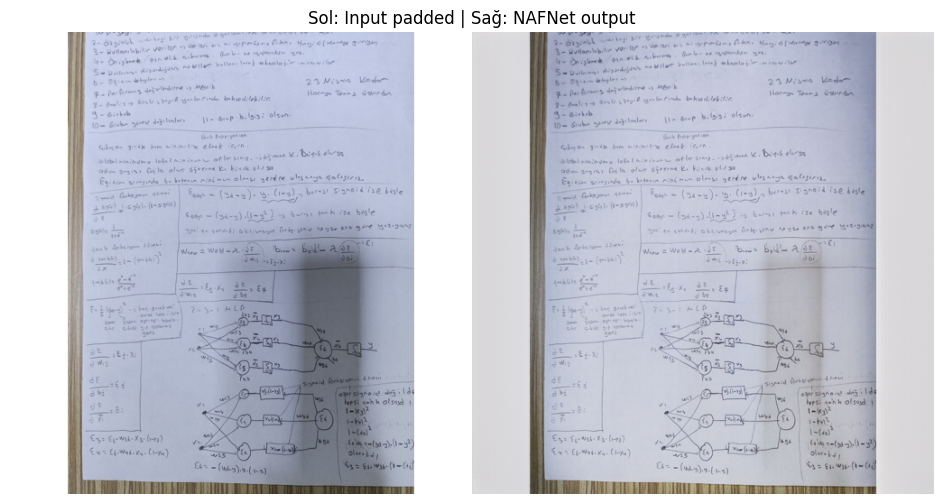

Enhanced: /content/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919/predictions/uploaded/IMG-20260429-WA0012_nafnet_enhanced.png
Compare: /content/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919/predictions/uploaded/IMG-20260429-WA0012_compare.png


In [12]:
# ============================================================
# 12) Run klasörünü Drive'a kopyala
# ============================================================

DRIVE_TARGET = DRIVE_RUNS_DIR / RUN_DIR.name
shutil.copytree(RUN_DIR, DRIVE_TARGET, dirs_exist_ok=True)
print("Drive'a kopyalandı:", DRIVE_TARGET)
print("Best checkpoint:", DRIVE_TARGET / "checkpoints" / "best.pt")

# ============================================================
# 11) Dosya yükleyerek inference testi
# ============================================================

from google.colab import files


def resize_pad_to_square(img: Image.Image, size=512):
    img = img.convert("RGB")
    w, h = img.size
    scale = size / max(w, h)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    img_resized = img.resize((nw, nh), Image.BICUBIC)
    canvas = Image.new("RGB", (size, size), (255, 255, 255))
    left = (size - nw) // 2
    top = (size - nh) // 2
    canvas.paste(img_resized, (left, top))
    return canvas


def pil_to_model_tensor(img: Image.Image, image_size=512):
    img = resize_pad_to_square(img, image_size)
    arr = np.array(img, dtype=np.float32) / 255.0
    ten = torch.from_numpy(arr).permute(2,0,1).unsqueeze(0).contiguous()
    return ten * 2.0 - 1.0, img


def load_best_model_for_inference(ckpt_path: Path):
    m = make_model(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    if ckpt.get("model_ema") is not None:
        m.load_state_dict(ckpt["model_ema"], strict=True)
        print("model_ema yüklendi")
    else:
        m.load_state_dict(ckpt["model"], strict=True)
        print("model yüklendi")
    m.to(device).eval()
    return m

best_path = CKPT_DIR / "best.pt"
if not best_path.exists():
    raise FileNotFoundError(f"best.pt bulunamadı: {best_path}")

infer_model = load_best_model_for_inference(best_path)
uploaded = files.upload()
OUT_DIR = PRED_DIR / "uploaded"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

for fname in uploaded.keys():
    img = Image.open(fname).convert("RGB")
    x, img_padded = pil_to_model_tensor(img, CFG.image_size)
    x = x.to(device)
    if CFG.use_channels_last:
        x = x.to(memory_format=torch.channels_last)
    with torch.no_grad():
        with autocast_context():
            y = infer_model(x)
    out = tensor_to_pil(y)

    stem = Path(fname).stem
    out_path = OUT_DIR / f"{stem}_nafnet_enhanced.png"
    cmp_path = OUT_DIR / f"{stem}_compare.png"
    out.save(out_path)

    canvas = Image.new("RGB", (CFG.image_size*2, CFG.image_size), "white")
    canvas.paste(img_padded, (0,0))
    canvas.paste(out, (CFG.image_size,0))
    canvas.save(cmp_path)

    plt.figure(figsize=(12,6))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title("Sol: Input padded | Sağ: NAFNet output")
    plt.show()
    print("Enhanced:", out_path)
    print("Compare:", cmp_path)


In [13]:
# ============================================================
# 12) Run klasörünü Drive'a kopyala
# ============================================================

DRIVE_TARGET = DRIVE_RUNS_DIR / RUN_DIR.name
shutil.copytree(RUN_DIR, DRIVE_TARGET, dirs_exist_ok=True)
print("Drive'a kopyalandı:", DRIVE_TARGET)
print("Best checkpoint:", DRIVE_TARGET / "checkpoints" / "best.pt")

Drive'a kopyalandı: /content/drive/MyDrive/ysaproj/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919
Best checkpoint: /content/drive/MyDrive/ysaproj/runs/board2notes_nafnet_small_h100_ramcache_full40_20260508_153919/checkpoints/best.pt
